<a href="https://colab.research.google.com/github/MohmmadSami/AI_Labs/blob/main/53199-Mohammad-Sami-Class-Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#   Topic: Confusion Matrix for Binary Classification
##  Class Activity  
##   10 Python Examples
---

| | |
|---|---|
| **Name** | Mohammad Sami |
| **SAP ID** | 53199 |
| **Course** | Artificial Intelligence (AI) |
| **Instructor** | Mr. Junaid Khan |
| **Topic** | Implementation of Confusion Matrix for Binary Classification |

---

##  What is a Confusion Matrix?

A **Confusion Matrix** is a performance evaluation tool for classification models. For **binary classification**, it is a 2×2 table that summarizes prediction results:

|  | **Predicted: Positive** | **Predicted: Negative** |
|---|---|---|
| **Actual: Positive** | True Positive (TP) | False Negative (FN) |
| **Actual: Negative** | False Positive (FP) | True Negative (TN) |

###  Key Metrics Derived from the Confusion Matrix:
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- **Precision** = TP / (TP + FP)
- **Recall (Sensitivity)** = TP / (TP + FN)
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)
- **Specificity** = TN / (TN + FP)

---


##  Required Libraries

In [13]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.datasets import (make_classification, load_breast_cancer,
                              make_blobs)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# Plotting settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


##  Helper Function (used throughout examples)

In [14]:
def plot_confusion_matrix(cm, title, labels=['Negative', 'Positive'],
                          cmap='Blues', figsize=(5, 4)):
    """Utility to display a styled confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                linewidths=1, linecolor='gray',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

def print_metrics(y_true, y_pred, model_name="Model"):
    """Print key classification metrics."""
    print(f"\n📊 Metrics — {model_name}")
    print("-" * 40)
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("-" * 40)

print(" Helper functions defined!")


 Helper functions defined!


---
##  Example 1 — Manual Confusion Matrix (Hard-coded Predictions)
**Concept:** Build a confusion matrix from manually defined actual vs predicted labels — perfect for beginners to understand the basics.


Confusion Matrix:
 [[8 2]
 [2 8]]

  TP=8  FP=2  FN=2  TN=8


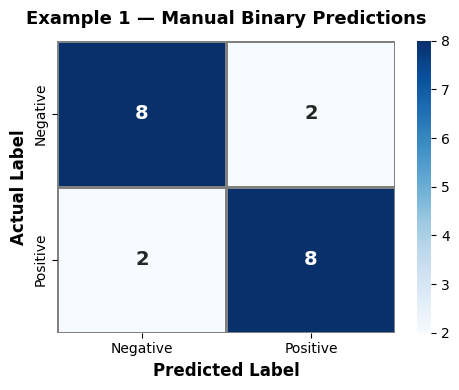


📊 Metrics — Manual Prediction
----------------------------------------
  Accuracy  : 0.8000
  Precision : 0.8000
  Recall    : 0.8000
  F1-Score  : 0.8000
----------------------------------------


In [15]:
# Manually defined labels (0 = Negative, 1 = Positive)
y_actual    = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
               1, 1, 0, 0, 1, 0, 1, 0, 0, 1]
y_predicted = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
               1, 0, 0, 0, 1, 1, 1, 0, 0, 1]

cm = confusion_matrix(y_actual, y_predicted)
print("Confusion Matrix:\n", cm)
print(f"\n  TP={cm[1,1]}  FP={cm[0,1]}  FN={cm[1,0]}  TN={cm[0,0]}")

plot_confusion_matrix(cm, "Example 1 — Manual Binary Predictions")
print_metrics(y_actual, y_predicted, "Manual Prediction")


---
##  Example 2 — Logistic Regression on Synthetic Data
**Concept:** Generate a synthetic binary classification dataset and train a Logistic Regression model, then evaluate it using a confusion matrix.


Confusion Matrix:
 [[46  3]
 [20 56]]


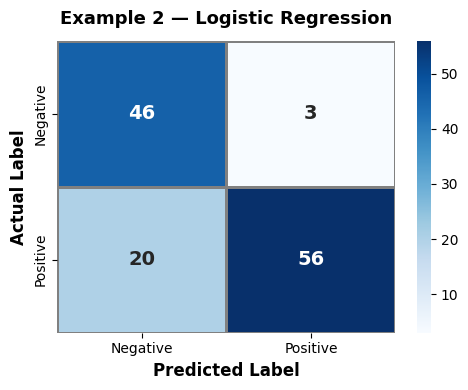


📊 Metrics — Logistic Regression
----------------------------------------
  Accuracy  : 0.8160
  Precision : 0.9492
  Recall    : 0.7368
  F1-Score  : 0.8296
----------------------------------------

Full Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.94      0.80        49
           1       0.95      0.74      0.83        76

    accuracy                           0.82       125
   macro avg       0.82      0.84      0.81       125
weighted avg       0.85      0.82      0.82       125



In [16]:
# Generate synthetic dataset
X, y = make_classification(n_samples=500, n_features=10,
                           n_informative=6, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                     random_state=42)

# Train Logistic Regression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plot_confusion_matrix(cm, "Example 2 — Logistic Regression")
print_metrics(y_test, y_pred, "Logistic Regression")
print("\nFull Classification Report:\n", classification_report(y_test, y_pred))


---
##  Example 3 — Decision Tree Classifier on Breast Cancer Dataset
**Concept:** Use the real-world Wisconsin Breast Cancer dataset (malignant vs benign) to evaluate a Decision Tree with a confusion matrix.


Dataset: Breast Cancer (Malignant=0, Benign=1)
Confusion Matrix:
 [[40  3]
 [ 3 68]]


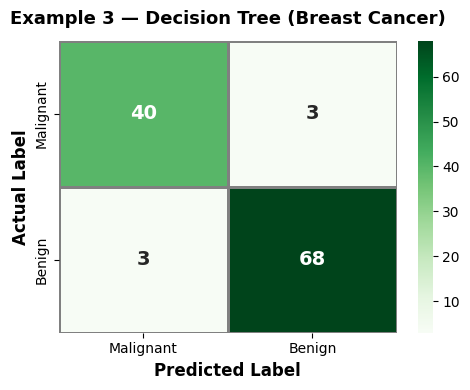


📊 Metrics — Decision Tree — Breast Cancer
----------------------------------------
  Accuracy  : 0.9474
  Precision : 0.9577
  Recall    : 0.9577
  F1-Score  : 0.9577
----------------------------------------


In [17]:
# Load real-world dataset
data = load_breast_cancer()
X, y = data.data, data.target           # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Dataset: Breast Cancer (Malignant=0, Benign=1)")
print("Confusion Matrix:\n", cm)

plot_confusion_matrix(cm, "Example 3 — Decision Tree (Breast Cancer)",
                      labels=['Malignant', 'Benign'], cmap='Greens')
print_metrics(y_test, y_pred, "Decision Tree — Breast Cancer")


---
##  Example 4 — Random Forest Classifier
**Concept:** Random Forest (ensemble of decision trees) often outperforms a single tree. Compare its confusion matrix with Example 3.


Random Forest — Confusion Matrix:
 [[40  3]
 [ 1 70]]


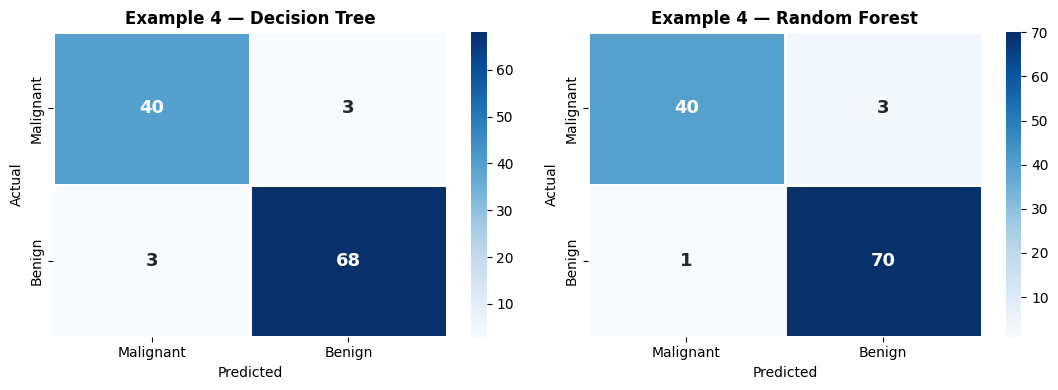


📊 Metrics — Random Forest — Breast Cancer
----------------------------------------
  Accuracy  : 0.9649
  Precision : 0.9589
  Recall    : 0.9859
  F1-Score  : 0.9722
----------------------------------------


In [18]:
# Reuse Breast Cancer split from Example 3
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest — Confusion Matrix:\n", cm_rf)

# Side-by-side comparison with Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm_val, title in zip(axes,
                              [cm, cm_rf],
                              ["Decision Tree", "Random Forest"]):
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant','Benign'],
                yticklabels=['Malignant','Benign'],
                linewidths=1, ax=ax, annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f"Example 4 — {title}", fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

print_metrics(y_test, y_pred_rf, "Random Forest — Breast Cancer")


---
##  Example 5 — Support Vector Machine (SVM)
**Concept:** SVM finds an optimal hyperplane to separate classes. Evaluate its binary classification performance using a confusion matrix on scaled data.


SVM Confusion Matrix:
 [[48  1]
 [ 0 51]]


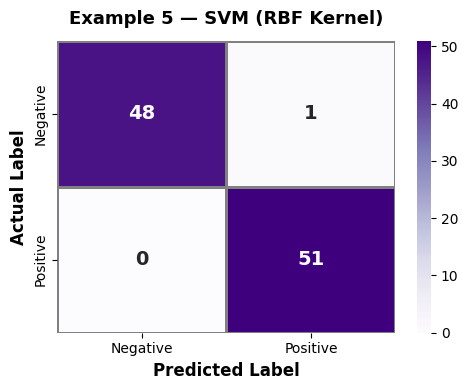


📊 Metrics — Support Vector Machine
----------------------------------------
  Accuracy  : 0.9900
  Precision : 0.9808
  Recall    : 1.0000
  F1-Score  : 0.9903
----------------------------------------


In [19]:
# Generate a clean 2-class blob dataset
X_blob, y_blob = make_blobs(n_samples=400, centers=2, cluster_std=1.8,
                             random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_blob, y_blob,
                                           test_size=0.25, random_state=42)

# Scale features (important for SVM)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# Train SVM
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_tr_sc, y_tr)
y_pred_svm = svm.predict(X_te_sc)

cm_svm = confusion_matrix(y_te, y_pred_svm)
print("SVM Confusion Matrix:\n", cm_svm)

plot_confusion_matrix(cm_svm, "Example 5 — SVM (RBF Kernel)", cmap='Purples')
print_metrics(y_te, y_pred_svm, "Support Vector Machine")


---
##  Example 6 — K-Nearest Neighbors (KNN)
**Concept:** KNN classifies based on the majority vote of K nearest training samples. Evaluate different values of K and their effect on the confusion matrix.


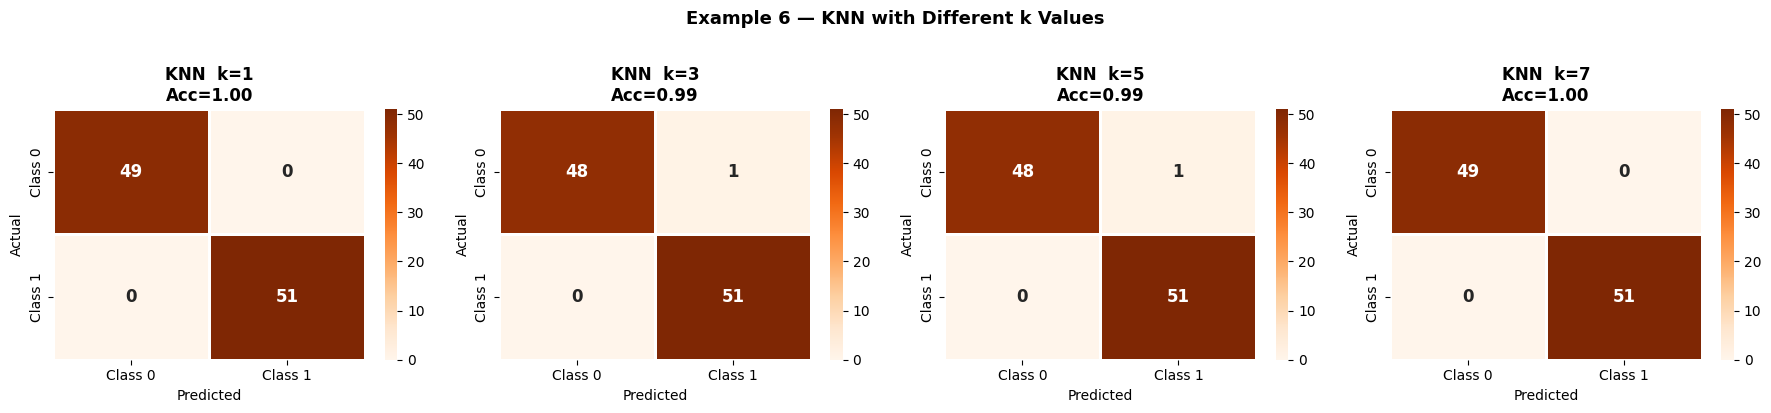

✅ KNN experiment complete — notice how accuracy changes with k!


In [20]:
# Reuse blob dataset (scaled) from Example 5
k_values = [1, 3, 5, 7]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_sc, y_tr)
    y_pred_k = knn.predict(X_te_sc)
    cm_k = confusion_matrix(y_te, y_pred_k)
    acc = accuracy_score(y_te, y_pred_k)
    sns.heatmap(cm_k, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Class 0','Class 1'],
                yticklabels=['Class 0','Class 1'],
                linewidths=1, annot_kws={'size':12,'weight':'bold'})
    ax.set_title(f"KNN  k={k}\nAcc={acc:.2f}", fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle("Example 6 — KNN with Different k Values", fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("✅ KNN experiment complete — notice how accuracy changes with k!")


---
##  Example 7 — Naïve Bayes Classifier
**Concept:** Gaussian Naïve Bayes is a probabilistic classifier based on Bayes' theorem. It is fast and works well for small datasets.


Naïve Bayes — Confusion Matrix:
 [[40  3]
 [ 1 70]]


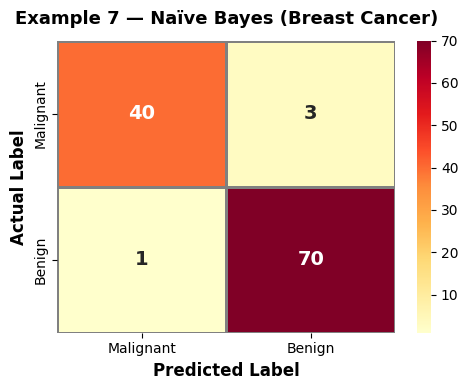


📊 Metrics — Gaussian Naïve Bayes
----------------------------------------
  Accuracy  : 0.9649
  Precision : 0.9589
  Recall    : 0.9859
  F1-Score  : 0.9722
----------------------------------------


In [21]:
# Reuse breast cancer split from Example 3
scaler2 = StandardScaler()
X_tr_sc2 = scaler2.fit_transform(X_train)
X_te_sc2  = scaler2.transform(X_test)

nb_model = GaussianNB()
nb_model.fit(X_tr_sc2, y_train)
y_pred_nb = nb_model.predict(X_te_sc2)

cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Naïve Bayes — Confusion Matrix:\n", cm_nb)

plot_confusion_matrix(cm_nb, "Example 7 — Naïve Bayes (Breast Cancer)",
                      labels=['Malignant', 'Benign'], cmap='YlOrRd')
print_metrics(y_test, y_pred_nb, "Gaussian Naïve Bayes")


---
##  Example 8 — Effect of Class Imbalance on Confusion Matrix
**Concept:** Class imbalance (many more negatives than positives) can fool accuracy. The confusion matrix reveals true performance.


Class distribution in test set: 0 → 221, 1 → 29
Imbalanced Dataset — Confusion Matrix:
 [[220   1]
 [ 23   6]]


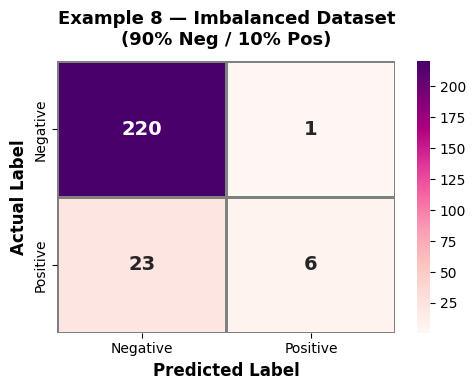


📊 Metrics — Logistic Regression (Imbalanced)
----------------------------------------
  Accuracy  : 0.9040
  Precision : 0.8571
  Recall    : 0.2069
  F1-Score  : 0.3333
----------------------------------------

⚠️  High accuracy but low recall = model ignores the minority class!


In [22]:
# Create heavily imbalanced dataset (90% Class 0, 10% Class 1)
X_imb, y_imb = make_classification(n_samples=1000, n_features=10,
                                    weights=[0.9, 0.1],
                                    n_informative=5, random_state=42)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_imb, y_imb,
                                                    test_size=0.25,
                                                    random_state=42)
print(f"Class distribution in test set: 0 → {(y_te_i==0).sum()}, "
      f"1 → {(y_te_i==1).sum()}")

# Train Logistic Regression
lr_imb = LogisticRegression(max_iter=300, random_state=42)
lr_imb.fit(X_tr_i, y_tr_i)
y_pred_imb = lr_imb.predict(X_te_i)

cm_imb = confusion_matrix(y_te_i, y_pred_imb)
print("Imbalanced Dataset — Confusion Matrix:\n", cm_imb)

plot_confusion_matrix(cm_imb, "Example 8 — Imbalanced Dataset\n(90% Neg / 10% Pos)",
                      cmap='RdPu')
print_metrics(y_te_i, y_pred_imb, "Logistic Regression (Imbalanced)")
print("\n⚠️  High accuracy but low recall = model ignores the minority class!")


---
##  Example 9 — Normalised Confusion Matrix (Percentage View)
**Concept:** A normalised confusion matrix shows proportions (0–1) instead of counts — useful when classes have different sizes.


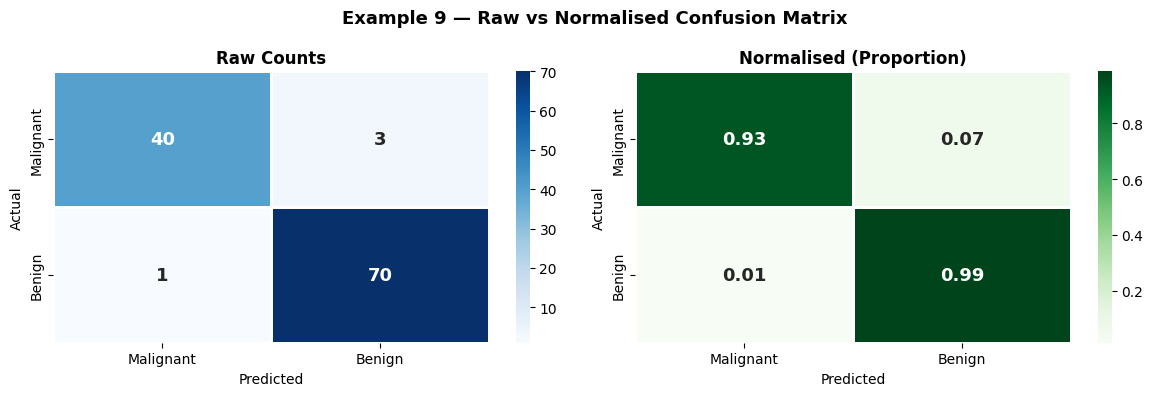

 Normalised matrix: rows sum to 1.0 — shows per-class rates clearly.


In [23]:
# Reuse Random Forest predictions from Example 4
cm_norm = confusion_matrix(y_test, y_pred_rf, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'],
            linewidths=1, annot_kws={'size':13,'weight':'bold'})
axes[0].set_title("Raw Counts", fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'],
            linewidths=1, annot_kws={'size':13,'weight':'bold'})
axes[1].set_title("Normalised (Proportion)", fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle("Example 9 — Raw vs Normalised Confusion Matrix",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(" Normalised matrix: rows sum to 1.0 — shows per-class rates clearly.")


---
##  Example 10 — Model Comparison Dashboard
**Concept:** Compare five classifiers side-by-side using both their confusion matrices and a bar chart of key metrics on the same dataset.


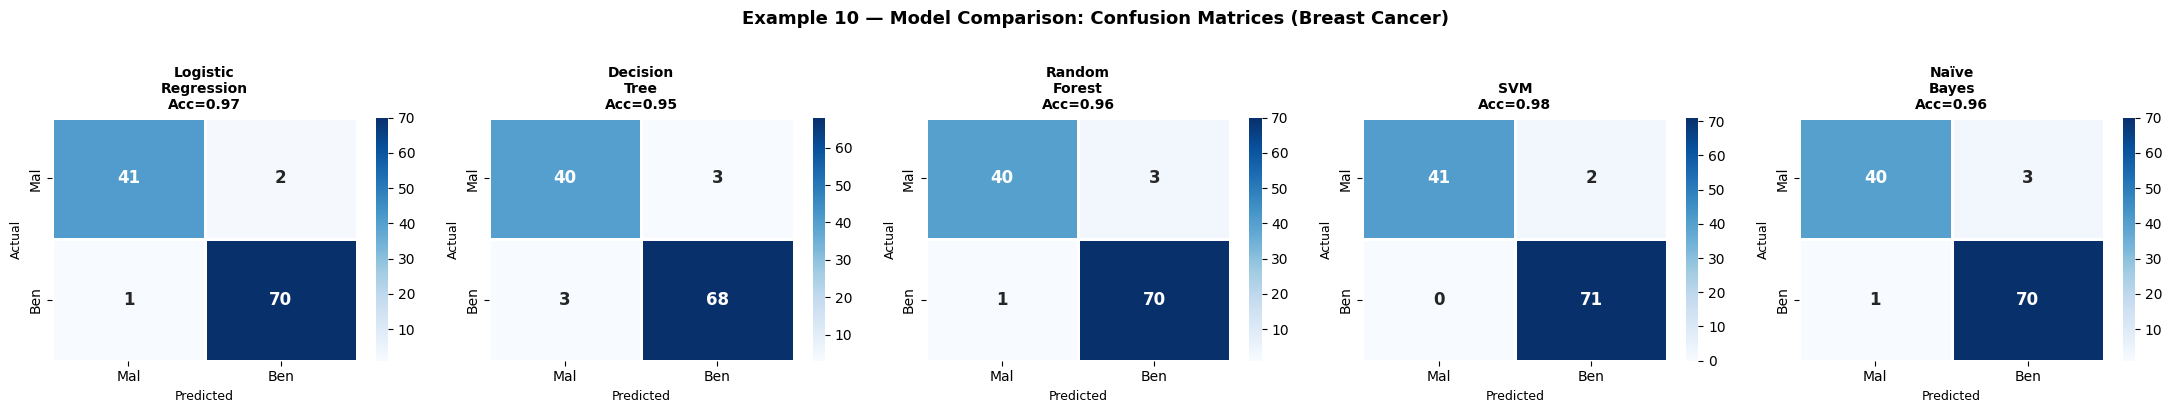

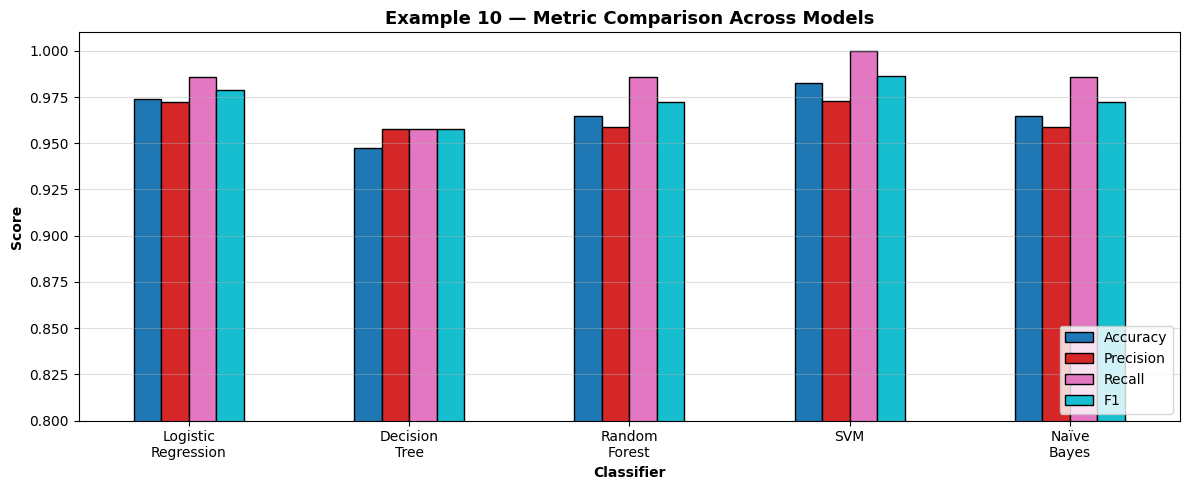


📊 Summary Table:
                      Accuracy  Precision  Recall     F1
Logistic\nRegression    0.9737     0.9722  0.9859 0.9790
Decision\nTree          0.9474     0.9577  0.9577 0.9577
Random\nForest          0.9649     0.9589  0.9859 0.9722
SVM                     0.9825     0.9726  1.0000 0.9861
Naïve\nBayes            0.9649     0.9589  0.9859 0.9722


In [24]:
# Dataset: Breast Cancer
X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(X_bc, y_bc,
                                                        test_size=0.2,
                                                        random_state=42)
sc = StandardScaler()
X_tr_bc_sc = sc.fit_transform(X_tr_bc)
X_te_bc_sc  = sc.transform(X_te_bc)

models = {
    "Logistic\nRegression" : LogisticRegression(max_iter=300, random_state=42),
    "Decision\nTree"       : DecisionTreeClassifier(random_state=42),
    "Random\nForest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                   : SVC(kernel='rbf', random_state=42),
    "Naïve\nBayes"         : GaussianNB(),
}

results = {}
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr_bc_sc, y_tr_bc)
    y_pr = model.predict(X_te_bc_sc)
    cm_m = confusion_matrix(y_te_bc, y_pr)
    results[name] = {
        'Accuracy' : accuracy_score(y_te_bc, y_pr),
        'Precision': precision_score(y_te_bc, y_pr, zero_division=0),
        'Recall'   : recall_score(y_te_bc, y_pr, zero_division=0),
        'F1'       : f1_score(y_te_bc, y_pr, zero_division=0),
    }
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Mal','Ben'], yticklabels=['Mal','Ben'],
                linewidths=1, annot_kws={'size':12,'weight':'bold'})
    acc = results[name]['Accuracy']
    ax.set_title(f"{name}\nAcc={acc:.2f}", fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)

plt.suptitle("Example 10 — Model Comparison: Confusion Matrices (Breast Cancer)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Metric Bar Chart ──────────────────────────────────────────────
df_res = pd.DataFrame(results).T
ax = df_res.plot(kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='black')
ax.set_ylim(0.80, 1.01)
ax.set_title("Example 10 — Metric Comparison Across Models",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Classifier", fontweight='bold')
ax.set_ylabel("Score", fontweight='bold')
ax.set_xticklabels(df_res.index, rotation=0, fontsize=10)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

print("\n📊 Summary Table:")
print(df_res.to_string(float_format="{:.4f}".format))


---
## 📝 Summary of All 10 Examples

| # | Example | Model / Concept | Dataset |
|---|---------|-----------------|---------|
| 1 | Manual Confusion Matrix | Hard-coded predictions | Custom |
| 2 | Logistic Regression | Linear probabilistic model | Synthetic |
| 3 | Decision Tree | Rule-based splitting | Breast Cancer |
| 4 | Random Forest | Ensemble of trees | Breast Cancer |
| 5 | Support Vector Machine | Hyperplane separator | Blobs |
| 6 | K-Nearest Neighbors | Distance-based voting | Blobs |
| 7 | Naïve Bayes | Probabilistic Bayesian | Breast Cancer |
| 8 | Class Imbalance | Effect on confusion matrix | Synthetic (90/10) |
| 9 | Normalised Matrix | Proportion view | Breast Cancer |
| 10 | Model Comparison Dashboard | All 5 models side-by-side | Breast Cancer |

---
> **Key Takeaway:** Accuracy alone can be misleading — always examine the full confusion matrix and its derived metrics (Precision, Recall, F1) to truly understand your model's performance.

---

